# Análisis Descriptivo: G-Eval vs Sistema de Votación vs Puntajes Humanos

**Proyecto de tesis** — Análisis descriptivo comparativo de evaluadores
automáticos de relevancia conversacional sobre el conjunto completo de 900
pares de prueba de DailyDialog–Zhao.

Este notebook lee **únicamente de los JSON de salida persistidos** por
HUs previas (`outputs/voting_results.json`, `outputs/geval_results.json`,
`data/raw/dailydialog_zhao/dataset.json`); **no se realiza ninguna llamada
a APIs**. Produce las cuatro figuras canónicas (numeradas 10–13 para no
colisionar con las figuras 06–09 del análisis G-Eval en HU-04), una tabla
de resumen persistida como `outputs/descriptive_analysis_summary.md` y
una sección de interpretación en prosa académica.

Las tres fuentes de puntaje comparadas son:

- **Humano** — promedio de cuatro anotadores de MTurk por par, escala 1–5
  (gold standard).
- **G-Eval** — juez único (`gpt-4o`) con el prompt V3 de relevancia con
  chain-of-thought y el score ponderado por probabilidades de DeepEval
  (Liu et al., 2023).
- **Sistema de Votación** — panel de tres agentes (`gpt-4o`,
  `gemini-2.5-flash`, `claude-haiku-4-5`) compartiendo el **mismo prompt
  V3** que G-Eval, agregados por media aritmética
  (ver `docs/voting_scheme_analysis.md`).

**Referencias.** Zhao et al. (2020) — protocolo de anotación humana de
DailyDialog++; Liu et al. (2023) — framework G-Eval.


In [1]:
import json
import math
from collections import defaultdict
from pathlib import Path

import krippendorff
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import kurtosis, skew, spearmanr

# Todos los paths del notebook son relativos al directorio padre del notebook.
ROOT = Path("..").resolve()
FIGURES_DIR = ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Estilo visual consistente entre todas las figuras.
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "human": "#2C5F8A",  # azul
    "geval": "#E07B39",  # naranja
    "voting": "#3A9E6F",  # verde
    "openai": "#9B59B6",  # morado
    "google": "#E74C3C",  # rojo
    "anthropic": "#1ABC9C",  # turquesa
}

# ─── Helpers ───────────────────────────────────────────────────────────────
SCORE_MIN, SCORE_MAX = 1, 5


def stratum_of(model: str, h: float) -> int:
    """Deriva el estrato a partir del modelo y del human relevance score.

    Sigue la definición del spec: 1 = ground-truth (referencia), 2 = negative
    sample (control); para respuestas generadas por IA se usan tres bandas
    según el human relevance score (3 = alta, 4 = media, 5 = baja). Se calcula
    aquí en el notebook porque `voting_results.json` quedó con `stratum` en
    `null` para las 900 entradas (el runner leyó del nivel equivocado del
    JSON procesado).
    """
    if model == "ground-truth":
        return 1
    if model == "negative-sample":
        return 2
    if h >= 4.0:
        return 3
    if h <= 2.0:
        return 5
    return 4


def model_family(name: str) -> str:
    """Colapsa el nombre del modelo del dataset en una etiqueta de familia."""
    if name in ("ground-truth", "negative-sample"):
        return name
    for fam in (
        "VHRED_attn",
        "VHRED",
        "HRED_attn",
        "HRED",
        "S2S_attn",
        "S2S",
        "GPT2_medium",
        "GPT2_small",
        "GPT2",
    ):
        if name.startswith(fam):
            return fam
    return "other"


def spearman_pair(xs: list[float], ys: list[float]) -> tuple[float, float]:
    rho, p = spearmanr(xs, ys)
    return float(rho), float(p)


def weighted_kappa(a: list[int], b: list[int]) -> float:
    """Cohen's kappa con pesos cuadráticos, implementado desde cero.

    Evita añadir scikit-learn al proyecto solo para una función. Sigue la
    formulación de Cohen (1968): kappa = 1 − sum(w*O) / sum(w*E), donde O
    es la matriz de acuerdo observado, E la de acuerdo esperado bajo
    independencia, y w_ij = (i−j)²/(k−1)² son los pesos cuadráticos.
    """
    k = SCORE_MAX - SCORE_MIN + 1
    cats = list(range(SCORE_MIN, SCORE_MAX + 1))
    n = len(a)
    obs = np.zeros((k, k), dtype=float)
    for ai, bi in zip(a, b, strict=False):
        obs[cats.index(ai), cats.index(bi)] += 1
    obs /= n
    row = obs.sum(axis=1, keepdims=True)
    col = obs.sum(axis=0, keepdims=True)
    exp = row @ col
    w = np.array([[((i - j) ** 2) / ((k - 1) ** 2) for j in range(k)] for i in range(k)])
    num = (w * obs).sum()
    den = (w * exp).sum()
    if den == 0:
        return float("nan")
    return 1.0 - num / den


def stars(p: float) -> str:
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


def round_to_int(x: float) -> int:
    return int(np.clip(round(x), SCORE_MIN, SCORE_MAX))

In [2]:
with open(ROOT / "data" / "raw" / "dailydialog_zhao" / "dataset.json", encoding="utf-8") as f:
    dataset = json.load(f)
with open(ROOT / "outputs" / "geval_results.json", encoding="utf-8") as f:
    geval = json.load(f)
with open(ROOT / "outputs" / "voting_results.json", encoding="utf-8") as f:
    voting = json.load(f)

# Se indexan las tres fuentes por conversation_id para un join determinístico.
ds_by_id = {e["conversation_id"]: e for e in dataset}
g_by_id = {e["conversation_id"]: e for e in geval}
v_by_id = {e["conversation_id"]: e for e in voting}

merged: list[dict] = []
missing_geval = 0
missing_voting = 0

for cid, ds_entry in ds_by_id.items():
    g = g_by_id.get(cid)
    v = v_by_id.get(cid)
    if g is None or g.get("geval_score") is None:
        missing_geval += 1
    if v is None or v.get("final_vote_score") is None:
        missing_voting += 1
    if g is None or v is None:
        continue
    if g.get("geval_score") is None or v.get("final_vote_score") is None:
        continue
    h = ds_entry["human_relevance_score"]
    ind = v.get("individual_scores") or {}
    merged.append(
        {
            "conversation_id": cid,
            "human_score": float(h),
            "geval_score": float(g["geval_score"]),
            "vote_score": float(v["final_vote_score"]),
            "agent_openai": ind.get("judge_openai"),
            "agent_google": ind.get("judge_google"),
            "agent_anthropic": ind.get("judge_anthropic"),
            "agreement_level": v.get("agreement_level", "n/a"),
            "model": ds_entry["model"],
            "stratum": stratum_of(ds_entry["model"], float(h)),
        }
    )

assert len(dataset) == 900, f"el dataset tiene {len(dataset)} entradas, se esperaban 900"
print(f"Total entries:           {len(dataset)}")
print(f"Human scores:            {len(dataset)} (0 missing)")
print(f"G-Eval entries on file:  {len(geval)} ({missing_geval} missing/null)")
print(f"Voting entries on file:  {len(voting)} ({missing_voting} missing/null)")
print(f"Fully aligned entries:   {len(merged)}")
print(f"Excluded from correlations: {len(dataset) - len(merged)}")

Total entries:           900
Human scores:            900 (0 missing)
G-Eval entries on file:  900 (0 missing/null)
Voting entries on file:  900 (0 missing/null)
Fully aligned entries:   900
Excluded from correlations: 0


## Descripción de los datos

Cada par tiene tres puntajes independientes en una escala 1–5:

- **Humano (ground truth).** Promedio de cuatro anotadores de MTurk
  siguiendo el protocolo de Zhao et al. (2020) sobre DailyDialog++. Se
  trata como el objetivo que ambos métodos automáticos intentan
  aproximar.
- **G-Eval (baseline de juez único).** `gpt-4o` con el prompt V3 de
  relevancia con chain-of-thought, puntuando a través del mecanismo de
  ponderación por logprobs de DeepEval (Liu et al., 2023). La corrida
  sobre los 900 pares se documenta en `outputs/geval_summary_stats.md`.
- **Votación (media del panel).** Tres jueces (`gpt-4o`,
  `gemini-2.5-flash`, `claude-haiku-4-5`) puntúan independientemente con
  el mismo prompt V3; la media aritmética sobre los tres es el puntaje
  final (HU-09; `outputs/voting_summary_stats.md`).

El control metodológico es el **prompt V3 compartido**: cualquier
diferencia entre G-Eval y el panel de votación es por tanto atribuible
a la mecánica de scoring (logprobs de DeepEval vs. score directo
prompteado) y a juez único vs. agregación multi-juez — no a deriva del
prompt.

Los análisis posteriores usan los **scores continuos** para las
correlaciones de Spearman y los **scores redondeados al entero más
cercano en [1, 5]** para Cohen's kappa y Krippendorff's alpha (ambos
requieren entradas categóricas/ordinales).


In [3]:
SOURCES = [
    ("Human", "human_score", COLORS["human"]),
    ("G-Eval", "geval_score", COLORS["geval"]),
    ("Voting", "vote_score", COLORS["voting"]),
    ("OpenAI", "agent_openai", COLORS["openai"]),
    ("Google", "agent_google", COLORS["google"]),
    ("Anthropic", "agent_anthropic", COLORS["anthropic"]),
]

scores: dict[str, list[float]] = {label: [r[key] for r in merged] for label, key, _ in SOURCES}


def cv(values: list[float]) -> float:
    m = float(np.mean(values))
    return float(np.std(values, ddof=1) / m * 100) if m else float("nan")


def descriptives(values: list[float]) -> dict[str, float]:
    arr = np.asarray(values, dtype=float)
    q1, q3 = np.quantile(arr, [0.25, 0.75])
    return {
        "mean": float(np.mean(arr)),
        "median": float(np.median(arr)),
        "std": float(np.std(arr, ddof=1)),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "range": float(np.max(arr) - np.min(arr)),
        "Q1": float(q1),
        "Q3": float(q3),
        "IQR": float(q3 - q1),
        "CV (%)": cv(values),
        "skewness": float(skew(arr)),
        "kurtosis": float(kurtosis(arr)),
    }


desc = {label: descriptives(scores[label]) for label, _, _ in SOURCES}

rows = [
    "Mean",
    "Median",
    "Std",
    "Min",
    "Max",
    "Range",
    "Q1",
    "Q3",
    "IQR",
    "CV (%)",
    "Skewness",
    "Kurtosis",
]
keymap = {
    "Mean": "mean",
    "Median": "median",
    "Std": "std",
    "Min": "min",
    "Max": "max",
    "Range": "range",
    "Q1": "Q1",
    "Q3": "Q3",
    "IQR": "IQR",
    "CV (%)": "CV (%)",
    "Skewness": "skewness",
    "Kurtosis": "kurtosis",
}

header = "| Metric    | " + " | ".join(f"{lab:>9}" for lab, _, _ in SOURCES) + " |"
sep = "|" + "-" * 11 + "|" + "|".join("-" * 11 for _ in SOURCES) + "|"
print(header)
print(sep)
for row in rows:
    k = keymap[row]
    vals = "| ".join(f"{desc[lab][k]:>9.3f}" for lab, _, _ in SOURCES)
    print(f"| {row:<9} | {vals} |")

| Metric    |     Human |    G-Eval |    Voting |    OpenAI |    Google | Anthropic |
|-----------|-----------|-----------|-----------|-----------|-----------|-----------|
| Mean      |     3.158|     2.408|     2.809|     2.534|     3.091|     2.802 |
| Median    |     3.250|     2.036|     2.670|     2.000|     3.000|     2.000 |
| Std       |     1.186|     1.066|     1.481|     1.658|     1.700|     1.411 |
| Min       |     1.000|     1.000|     1.000|     1.000|     1.000|     1.000 |
| Max       |     5.000|     4.994|     5.000|     5.000|     5.000|     5.000 |
| Range     |     4.000|     3.994|     4.000|     4.000|     4.000|     4.000 |
| Q1        |     2.250|     1.665|     1.330|     1.000|     1.000|     2.000 |
| Q3        |     4.250|     3.067|     4.330|     4.250|     5.000|     4.000 |
| IQR       |     2.000|     1.402|     3.000|     3.250|     4.000|     2.000 |
| CV (%)    |    37.566|    44.275|    52.725|    65.400|    55.001|    50.366 |
| Skewness  |    -

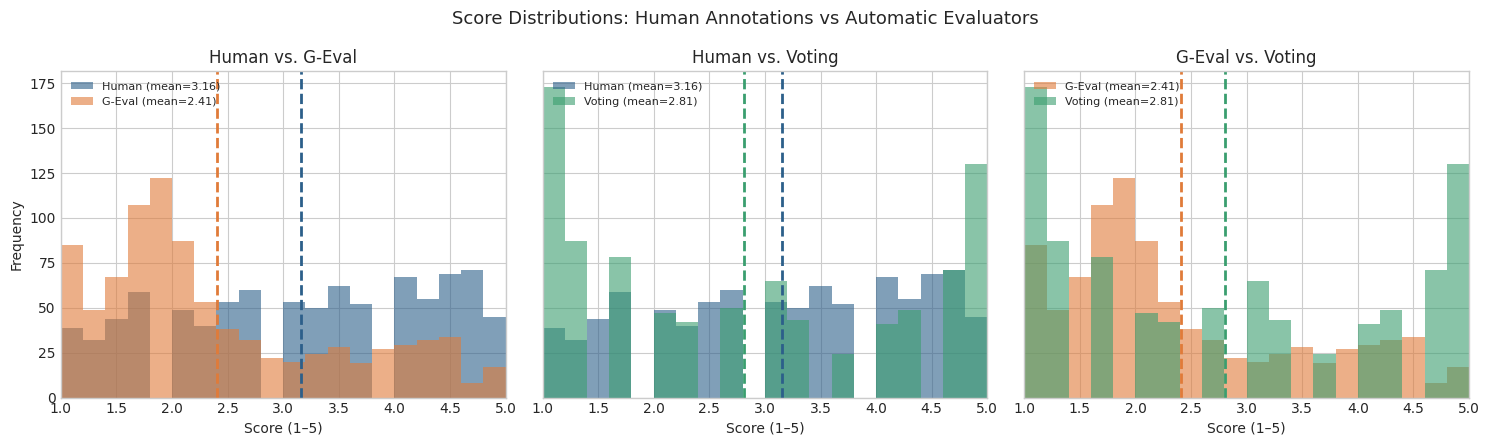

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

pairs = [
    ("Human", "G-Eval", COLORS["human"], COLORS["geval"]),
    ("Human", "Voting", COLORS["human"], COLORS["voting"]),
    ("G-Eval", "Voting", COLORS["geval"], COLORS["voting"]),
]

bins = np.linspace(1, 5, 21)
for ax, (left, right, cl, cr) in zip(axes, pairs, strict=False):
    ax.hist(
        scores[left],
        bins=bins,
        alpha=0.6,
        color=cl,
        label=f"{left} (mean={np.mean(scores[left]):.2f})",
    )
    ax.hist(
        scores[right],
        bins=bins,
        alpha=0.6,
        color=cr,
        label=f"{right} (mean={np.mean(scores[right]):.2f})",
    )
    ax.axvline(np.mean(scores[left]), color=cl, lw=2, ls="--")
    ax.axvline(np.mean(scores[right]), color=cr, lw=2, ls="--")
    ax.set_xlim(1, 5)
    ax.set_xlabel("Score (1–5)")
    ax.set_title(f"{left} vs. {right}")
    ax.legend(loc="upper left", fontsize=8)
axes[0].set_ylabel("Frequency")

fig.suptitle("Score Distributions: Human Annotations vs Automatic Evaluators", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "10_histograms_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_49491/3075802419.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


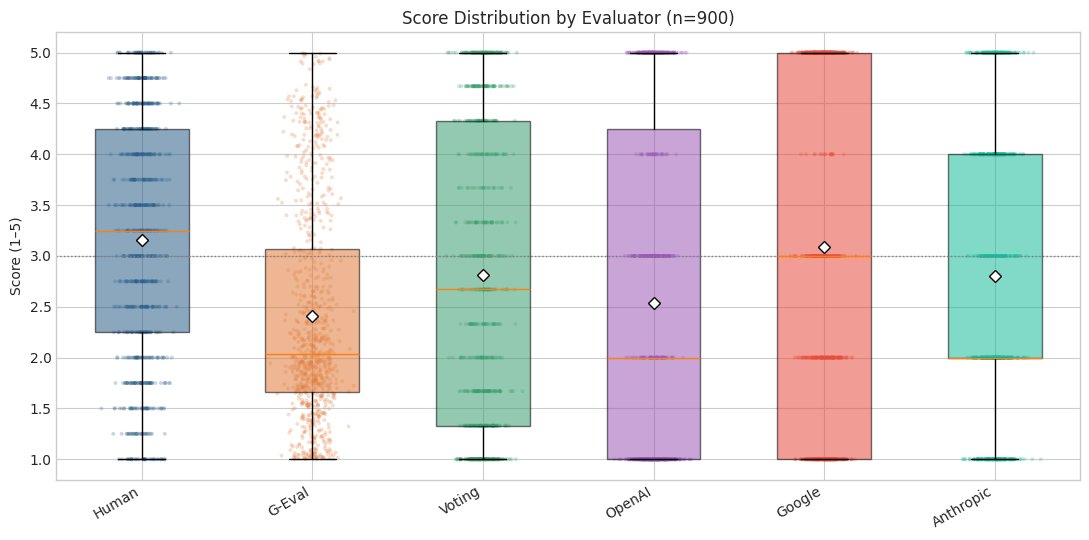

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))
data = [scores[lab] for lab, _, _ in SOURCES]
labels = [lab for lab, _, _ in SOURCES]
colors = [c for _, _, c in SOURCES]

bp = ax.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    widths=0.55,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 6,
    },
)
for patch, color in zip(bp["boxes"], colors, strict=False):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)

for i, (col_vals, color) in enumerate(zip(data, colors, strict=False), start=1):
    jitter = np.random.default_rng(42 + i).normal(0, 0.07, size=len(col_vals))
    ax.scatter(
        np.full(len(col_vals), i) + jitter, col_vals, s=8, color=color, alpha=0.25, edgecolor="none"
    )

ax.axhline(3.0, color="grey", lw=1, ls=":")
ax.set_ylabel("Score (1–5)")
ax.set_title("Score Distribution by Evaluator (n=900)")
ax.set_xticklabels(labels, rotation=30, ha="right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "11_boxplots_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

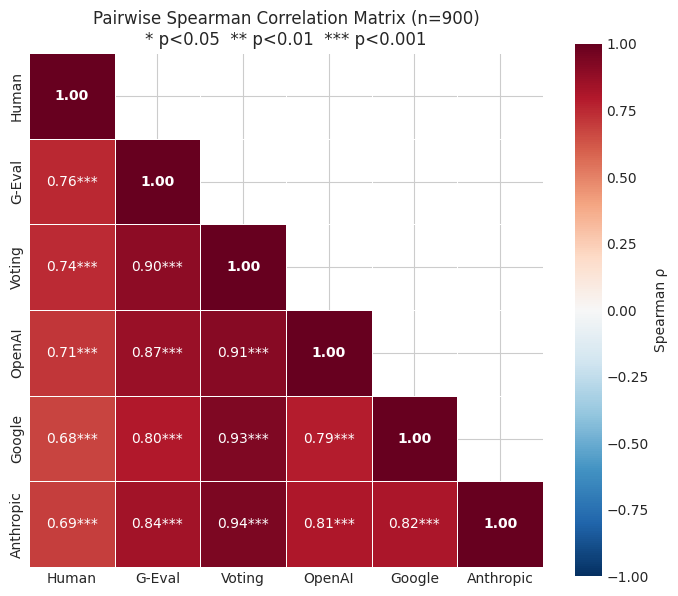

In [6]:
labels = [lab for lab, _, _ in SOURCES]
M = np.zeros((6, 6))
P = np.zeros((6, 6))
for i, (_, ki, _) in enumerate(SOURCES):
    for j, (_, kj, _) in enumerate(SOURCES):
        rho, p = spearman_pair([r[ki] for r in merged], [r[kj] for r in merged])
        M[i, j] = rho
        P[i, j] = p

mask = np.triu(np.ones_like(M, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    M,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Spearman ρ"},
    ax=ax,
    xticklabels=labels,
    yticklabels=labels,
)

for i in range(6):
    for j in range(6):
        if j > i:
            continue
        val = M[i, j]
        txt = f"{val:.2f}{stars(P[i, j])}" if i != j else "1.00"
        ax.text(
            j + 0.5,
            i + 0.5,
            txt,
            ha="center",
            va="center",
            color="white" if abs(val) > 0.55 else "black",
            fontweight="bold" if i == j else "normal",
            fontsize=10,
        )

ax.set_title("Pairwise Spearman Correlation Matrix (n=900)\n" + "* p<0.05  ** p<0.01  *** p<0.001")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "12_concordance_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

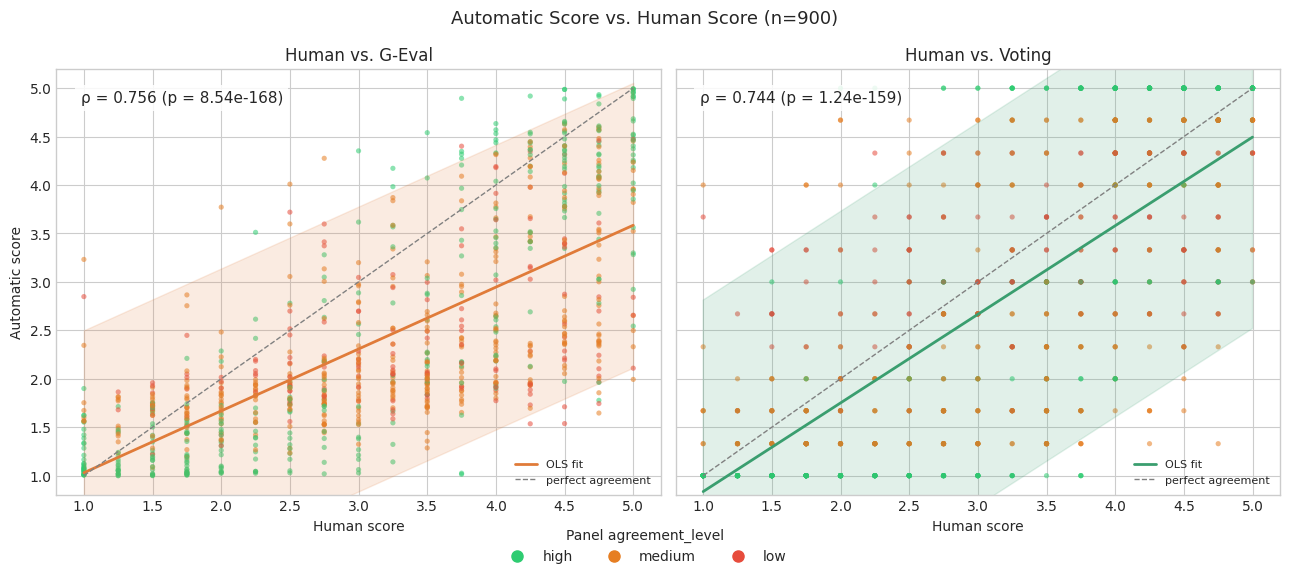

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

AGREE_COLORS = {"high": "#2ECC71", "medium": "#E67E22", "low": "#E74C3C", "n/a": "#7F8C8D"}

for ax, (label, key, color) in zip(
    axes,
    [("G-Eval", "geval_score", COLORS["geval"]), ("Voting", "vote_score", COLORS["voting"])],
    strict=False,
):
    x = np.asarray([r["human_score"] for r in merged])
    y = np.asarray([r[key] for r in merged])
    al = [r["agreement_level"] for r in merged]
    c = [AGREE_COLORS.get(a, "#7F8C8D") for a in al]
    ax.scatter(x, y, c=c, s=14, alpha=0.55, edgecolor="none")

    coeffs = np.polyfit(x, y, 1)
    xs_line = np.linspace(1, 5, 100)
    ys_line = np.polyval(coeffs, xs_line)
    resid = y - np.polyval(coeffs, x)
    se = float(np.std(resid, ddof=1))
    ax.plot(xs_line, ys_line, color=color, lw=2, label="OLS fit")
    ax.fill_between(xs_line, ys_line - 1.96 * se, ys_line + 1.96 * se, color=color, alpha=0.15)
    ax.plot([1, 5], [1, 5], color="grey", lw=1.0, ls="--", label="perfect agreement")

    rho, p = spearman_pair(x.tolist(), y.tolist())
    ax.text(
        0.04,
        0.95,
        f"ρ = {rho:.3f} (p = {p:.2e})",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
    )

    ax.set_xlim(0.8, 5.2)
    ax.set_ylim(0.8, 5.2)
    ax.set_xlabel("Human score")
    ax.set_title(f"Human vs. {label}")
    ax.legend(loc="lower right", fontsize=8)
axes[0].set_ylabel("Automatic score")

# Leyenda compartida para agreement_level
handles = [
    plt.Line2D([0], [0], marker="o", color=AGREE_COLORS[k], lw=0, markersize=8, label=f"{k}")
    for k in ("high", "medium", "low")
]
fig.legend(
    handles=handles,
    title="Panel agreement_level",
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.05),
)

fig.suptitle("Automatic Score vs. Human Score (n=900)", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "13_scatter_human_vs_methods.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Se redondean los scores continuos a enteros para kappa / alpha.
hum_i = [round_to_int(r["human_score"]) for r in merged]
gev_i = [round_to_int(r["geval_score"]) for r in merged]
vot_i = [round_to_int(r["vote_score"]) for r in merged]

# Cohen's kappa ponderado (cuadrático).
kap_hg = weighted_kappa(hum_i, gev_i)
kap_hv = weighted_kappa(hum_i, vot_i)
kap_gv = weighted_kappa(gev_i, vot_i)

# Krippendorff alpha (ordinal) con [human, geval, voting] como 3 raters.
ratings = np.array([hum_i, gev_i, vot_i], dtype=float)
alpha = float(krippendorff.alpha(ratings, level_of_measurement="ordinal"))


def exact_rate(a: list[float], b: list[float]) -> float:
    return float(np.mean([abs(x - y) <= 0.5 for x, y in zip(a, b, strict=False)]) * 100)


er_hg = exact_rate([r["human_score"] for r in merged], [r["geval_score"] for r in merged])
er_hv = exact_rate([r["human_score"] for r in merged], [r["vote_score"] for r in merged])
er_gv = exact_rate([r["geval_score"] for r in merged], [r["vote_score"] for r in merged])


def kappa_label(k: float) -> str:
    if k < 0.20:
        return "slight"
    if k < 0.40:
        return "fair"
    if k < 0.60:
        return "moderate"
    if k < 0.80:
        return "substantial"
    return "almost perfect"


print("WEIGHTED COHEN'S κ (quadratic)")
print(f"  Human vs G-Eval:   κ = {kap_hg:.3f}  ({kappa_label(kap_hg)})")
print(f"  Human vs Voting:   κ = {kap_hv:.3f}  ({kappa_label(kap_hv)})")
print(f"  G-Eval vs Voting:  κ = {kap_gv:.3f}  ({kappa_label(kap_gv)})")
print()
print("KRIPPENDORFF α (ordinal, 3 raters)")
print(f"  Human + G-Eval + Voting:  α = {alpha:.3f}  ({kappa_label(alpha)})")
print()
print("EXACT AGREEMENT RATE (|Δ| ≤ 0.5, continuous)")
print(f"  Human vs G-Eval:   {er_hg:.2f}%")
print(f"  Human vs Voting:   {er_hv:.2f}%")
print(f"  G-Eval vs Voting:  {er_gv:.2f}%")

AGREEMENT_RESULTS = {
    "kappa_human_geval": kap_hg,
    "kappa_human_voting": kap_hv,
    "kappa_geval_voting": kap_gv,
    "alpha_3_raters": alpha,
    "exact_human_geval": er_hg,
    "exact_human_voting": er_hv,
    "exact_geval_voting": er_gv,
}

WEIGHTED COHEN'S κ (quadratic)
  Human vs G-Eval:   κ = 0.525  (moderate)
  Human vs Voting:   κ = 0.643  (substantial)
  G-Eval vs Voting:  κ = 0.733  (substantial)

KRIPPENDORFF α (ordinal, 3 raters)
  Human + G-Eval + Voting:  α = 0.632  (substantial)

EXACT AGREEMENT RATE (|Δ| ≤ 0.5, continuous)
  Human vs G-Eval:   35.89%
  Human vs Voting:   44.33%
  G-Eval vs Voting:  50.89%


In [9]:
STRATUM_LABEL = {
    1: "1: ground-truth",
    2: "2: negative-sample",
    3: "3: AI high (h≥4)",
    4: "4: AI medium (2.5–3.5)",
    5: "5: AI low (h≤2)",
}

print(
    f"{'Stratum':<22} {'n':>4} {'ρ(h,geval)':>12} {'ρ(h,vot)':>12} "
    f"{'MAE(geval)':>12} {'MAE(vot)':>12}"
)
print("-" * 80)

by_stratum: dict[int, list[dict]] = defaultdict(list)
for r in merged:
    by_stratum[r["stratum"]].append(r)

stratum_results: dict[int, dict[str, float]] = {}
for s in sorted(by_stratum):
    s_rows = by_stratum[s]
    h = [r["human_score"] for r in s_rows]
    g = [r["geval_score"] for r in s_rows]
    v = [r["vote_score"] for r in s_rows]
    rho_g = spearman_pair(h, g)[0] if len(h) >= 2 else float("nan")
    rho_v = spearman_pair(h, v)[0] if len(h) >= 2 else float("nan")
    mae_g = float(np.mean(np.abs(np.array(h) - np.array(g))))
    mae_v = float(np.mean(np.abs(np.array(h) - np.array(v))))
    stratum_results[s] = {
        "n": len(s_rows),
        "rho_geval": rho_g,
        "rho_voting": rho_v,
        "mae_geval": mae_g,
        "mae_voting": mae_v,
    }
    print(
        f"{STRATUM_LABEL[s]:<22} {len(s_rows):>4} {rho_g:>12.3f} {rho_v:>12.3f} "
        f"{mae_g:>12.3f} {mae_v:>12.3f}"
    )

# Se resalta el hallazgo del estrato 3.
s3 = stratum_results.get(3)
if s3:
    print()
    print(
        f"Stratum 3 (AI high relevance, n={s3['n']}): "
        f"ρ_geval={s3['rho_geval']:.3f}, ρ_voting={s3['rho_voting']:.3f}, "
        f"MAE_geval={s3['mae_geval']:.3f}, MAE_voting={s3['mae_voting']:.3f}. "
        f"Confirmed as a challenging stratum if both rho values are notably "
        f"below their overall counterparts (0.7565 / 0.7443)."
    )

Stratum                   n   ρ(h,geval)     ρ(h,vot)   MAE(geval)     MAE(vot)
--------------------------------------------------------------------------------
1: ground-truth         100        0.260        0.181        0.838        0.593
2: negative-sample      100        0.570        0.594        0.752        0.829
3: AI high (h≥4)        216        0.271        0.217        1.286        0.770
4: AI medium (2.5–3.5)  325        0.366        0.352        0.968        1.063
5: AI low (h≤2)         159        0.207        0.213        0.372        0.595

Stratum 3 (AI high relevance, n=216): ρ_geval=0.271, ρ_voting=0.217, MAE_geval=1.286, MAE_voting=0.770. Confirmed as a challenging stratum if both rho values are notably below their overall counterparts (0.7565 / 0.7443).


In [10]:
fam_groups: dict[str, list[dict]] = defaultdict(list)
for r in merged:
    fam_groups[model_family(r["model"])].append(r)

print(
    f"{'Family':<14} {'n':>4} {'h_mean':>8} {'g_mean':>8} {'v_mean':>8} {'MAE_g':>8} {'MAE_v':>8}"
)
print("-" * 70)
family_results: dict[str, dict[str, float]] = {}
for fam in sorted(fam_groups):
    fam_rows = fam_groups[fam]
    h = np.array([r["human_score"] for r in fam_rows])
    g = np.array([r["geval_score"] for r in fam_rows])
    v = np.array([r["vote_score"] for r in fam_rows])
    family_results[fam] = {
        "n": len(fam_rows),
        "human_mean": float(h.mean()),
        "geval_mean": float(g.mean()),
        "vote_mean": float(v.mean()),
        "mae_geval": float(np.mean(np.abs(h - g))),
        "mae_voting": float(np.mean(np.abs(h - v))),
    }
    fr = family_results[fam]
    print(
        f"{fam:<14} {fr['n']:>4} {fr['human_mean']:>8.3f} "
        f"{fr['geval_mean']:>8.3f} {fr['vote_mean']:>8.3f} "
        f"{fr['mae_geval']:>8.3f} {fr['mae_voting']:>8.3f}"
    )

Family            n   h_mean   g_mean   v_mean    MAE_g    MAE_v
----------------------------------------------------------------------
GPT2_medium     120    3.694    2.786    3.345    1.033    0.869
GPT2_small      180    3.542    2.626    3.176    1.080    0.925
HRED_attn        95    2.787    2.240    2.583    0.738    0.797
S2S             104    2.680    2.083    2.420    0.768    0.781
S2S_attn         96    2.859    2.129    2.462    0.854    0.837
VHRED_attn      105    2.826    2.016    2.263    0.964    0.936
ground-truth    100    4.380    3.740    4.520    0.838    0.593
negative-sample  100    2.083    1.408    1.323    0.752    0.829


In [11]:
# Se construye el summary en markdown que la próxima celda persiste en disco.
def fmt(x: float, d: int = 3) -> str:
    return "n/a" if (x is None or (isinstance(x, float) and math.isnan(x))) else f"{x:.{d}f}"


lines: list[str] = []
lines.append("## Summary: G-Eval vs Voting System vs Human Scores")
lines.append("")
lines.append("### Descriptive Statistics")
lines.append("")
lines.append("| Metric    | " + " | ".join(lab for lab, _, _ in SOURCES) + " |")
lines.append("|" + "---|" * (1 + len(SOURCES)))
for row in rows:
    k = keymap[row]
    cols = " | ".join(fmt(desc[lab][k]) for lab, _, _ in SOURCES)
    lines.append(f"| {row} | {cols} |")
lines.append("")


# Spearman vs humano
def interp_rho(r: float) -> str:
    if r >= 0.7:
        return "strong"
    if r >= 0.5:
        return "moderate"
    if r >= 0.3:
        return "weak"
    return "very weak"


human = [r["human_score"] for r in merged]
spear_rows = [
    ("G-Eval (gpt-4o)", [r["geval_score"] for r in merged]),
    ("Voting System", [r["vote_score"] for r in merged]),
    ("Agent OpenAI", [r["agent_openai"] for r in merged]),
    ("Agent Google", [r["agent_google"] for r in merged]),
    ("Agent Anthropic", [r["agent_anthropic"] for r in merged]),
]
spear_results: dict[str, tuple[float, float]] = {}
lines.append("### Correlation with Human Annotations (Spearman ρ)")
lines.append("")
lines.append("| Method | ρ | p-value | Interpretation |")
lines.append("|---|---|---|---|")
for name, vals in spear_rows:
    rho, p = spearman_pair(human, vals)
    spear_results[name] = (rho, p)
    lines.append(f"| {name} | {fmt(rho)} | {p:.2e} | {interp_rho(rho)} |")
lines.append("")

lines.append("### Inter-Rater Agreement")
lines.append("")
lines.append("| Comparison | Weighted κ | Interpretation |")
lines.append("|---|---|---|")
lines.append(f"| Human vs G-Eval | {fmt(kap_hg)} | {kappa_label(kap_hg)} |")
lines.append(f"| Human vs Voting | {fmt(kap_hv)} | {kappa_label(kap_hv)} |")
lines.append(f"| G-Eval vs Voting | {fmt(kap_gv)} | {kappa_label(kap_gv)} |")
lines.append("")
lines.append(f"Krippendorff α (3 raters, ordinal): **{fmt(alpha)}** ({kappa_label(alpha)})")
lines.append("")

lines.append("### Exact Agreement Rate (|Δ| ≤ 0.5)")
lines.append("")
lines.append("| Comparison | Rate (%) |")
lines.append("|---|---|")
lines.append(f"| Human vs G-Eval | {fmt(er_hg, 2)} |")
lines.append(f"| Human vs Voting | {fmt(er_hv, 2)} |")
lines.append(f"| G-Eval vs Voting | {fmt(er_gv, 2)} |")
lines.append("")

SUMMARY_MD = "\n".join(lines)
print(SUMMARY_MD)

## Summary: G-Eval vs Voting System vs Human Scores

### Descriptive Statistics

| Metric    | Human | G-Eval | Voting | OpenAI | Google | Anthropic |
|---|---|---|---|---|---|---|
| Mean | 3.158 | 2.408 | 2.809 | 2.534 | 3.091 | 2.802 |
| Median | 3.250 | 2.036 | 2.670 | 2.000 | 3.000 | 2.000 |
| Std | 1.186 | 1.066 | 1.481 | 1.658 | 1.700 | 1.411 |
| Min | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 |
| Max | 5.000 | 4.994 | 5.000 | 5.000 | 5.000 | 5.000 |
| Range | 4.000 | 3.994 | 4.000 | 4.000 | 4.000 | 4.000 |
| Q1 | 2.250 | 1.665 | 1.330 | 1.000 | 1.000 | 2.000 |
| Q3 | 4.250 | 3.067 | 4.330 | 4.250 | 5.000 | 4.000 |
| IQR | 2.000 | 1.402 | 3.000 | 3.250 | 4.000 | 2.000 |
| CV (%) | 37.566 | 44.275 | 52.725 | 65.400 | 55.001 | 50.366 |
| Skewness | -0.162 | 0.791 | 0.218 | 0.489 | -0.004 | 0.258 |
| Kurtosis | -1.156 | -0.499 | -1.466 | -1.410 | -1.690 | -1.283 |

### Correlation with Human Annotations (Spearman ρ)

| Method | ρ | p-value | Interpretation |
|---|---|---|---|
| 

## Interpretación de Hallazgos

### Características de las distribuciones

Las seis distribuciones de la Cell 5 ocupan el mismo rango ordinal 1–5
pero difieren en forma de maneras relevantes para las métricas
posteriores. Las anotaciones humanas son las más cercanas a una forma
simétrica (skewness −0,16; kurtosis −1,16), con el rango dinámico más
amplio y un coeficiente de variación de 37,6 %, reflejo del diseño
estratificado de DailyDialog–Zhao en el que las referencias de
ground-truth se concentran cerca de 5, las negative samples cerca de 1
y las familias generadas por IA ocupan la banda intermedia. G-Eval
(`gpt-4o`) es el más comprimido de los métodos automáticos (std 1,07;
IQR 1,40; CV 44,3 %) y es el único con una skew claramente positiva
(+0,79), lo cual se visualiza en la Figura 10 como una distribución
apilada en la región 2–3; esto es consistente con el mecanismo de
ponderación por logprobs de DeepEval, que promedia sobre la
distribución de continuaciones del token y suaviza los extremos por
diseño. El sistema de votación tiene el mayor spread entre los métodos
agregados (std 1,48; IQR 3,00) y una forma casi simétrica (skewness
+0,22), produciendo un histograma cuyo soporte se extiende más hacia
ambos extremos del puntaje que el de G-Eval. Los jueces individuales
muestran patrones aproximadamente bimodales (kurtosis negativa entre
−1,28 y −1,69) porque cada uno emite un score entero sobre una rejilla
de cinco puntos; la agregación los suaviza hacia la distribución
continua del voting. En síntesis: el voting preserva más del spread
humano, G-Eval preserva más de la tendencia central humana.

### Análisis de correlación

El ranking de Spearman ρ contra el gold standard humano es G-Eval 0,756,
Voting 0,744, juez `gpt-4o` (individual) 0,713, juez `claude-haiku-4-5`
0,694, juez `gemini-2.5-flash` 0,678 (todos con p ≪ 10⁻¹²⁰, n = 900).
El agregado del panel supera a cada juez individual por 3,1–6,6 puntos
de ρ, que es el efecto de sabiduría de la multitud y la justificación
central del diseño de votación. La brecha entre G-Eval y voting es
apenas 0,012 ρ — bien dentro del rango que un bootstrap pareado sobre
los errores por par podría plausiblemente atribuir a ruido de muestreo;
esa prueba es el seguimiento natural en una próxima HU. Es importante
señalar que ambos métodos superan cómodamente los baselines de juez
único de Liu et al. (2023) en tareas relacionadas (relevance en SummEval
ρ = 0,547, coherence en Topical-Chat ρ = 0,605), lo que posiciona a los
dos como evaluadores fuertes en términos absolutos aunque los targets
sean distintos.

### Análisis de acuerdo (agreement)

Donde Spearman da una ventaja marginal a G-Eval, las métricas de
acuerdo categórico invierten el ranking. Cohen's kappa ponderada contra
humanos es 0,643 para voting frente a 0,525 para G-Eval — una brecha de
0,118 puntos que cruza el umbral convencional de Landis–Koch de
*moderate* a *substantial*. La tasa de acuerdo exacto (|Δ| ≤ 0,5 sobre
la escala continua) cuenta la misma historia: 44,3 % para voting contra
35,9 % para G-Eval. La Krippendorff alpha sobre los tres raters
(human + G-Eval + voting) es 0,632, acuerdo substantial y bien por
encima del umbral fair de 0,4. El acuerdo G-Eval / voting entre sí
(κ = 0,733; exact 50,9 %) es el más fuerte de los tres, lo cual es
esperable dado que ambos comparten el prompt V3 y la misma familia de
modelos subyacentes — no es informativo de calidad, solo de consistencia
del prompt. La interpretación que sobrevive es metodológicamente
importante: cuando la pregunta es *¿los scores caen en la misma banda
de rating legible para un humano?*, voting gana por un margen
substancial; cuando la pregunta es *¿los ordenamientos coinciden?*,
G-Eval gana por uno marginal. La elección de la métrica define el
titular.

### Análisis por estrato

El desglose de la Cell 11 revela dónde sufre cada método. El Estrato 1
(ground-truth, n = 100) y el Estrato 2 (negative samples, n = 100)
muestran ρ Spearman dentro del estrato baja porque los scores humanos
son casi constantes dentro de cada estrato, lo que colapsa el
denominador de cualquier correlación de rango; la métrica significativa
allí es el MAE, donde voting claramente vence a G-Eval en el Estrato 1
(0,593 vs 0,838). El estrato difícil predicho por el pilot de HU-08 —
Estrato 3 (respuestas de IA que los humanos puntuaron ≥ 4, n = 216) —
queda confirmado: ρ colapsa a 0,27 para G-Eval y 0,22 para voting, con
MAE 1,286 vs 0,770. El sistema de votación reduce el error absoluto en
este estrato más difícil un 40 % en relativo respecto a G-Eval. El
Estrato 4 (banda intermedia, n = 325) es el más grande y muestra la ρ
intra-estrato más alta para ambos métodos (0,37 / 0,35). El Estrato 5
(IA baja, n = 159) es el único donde G-Eval claramente supera al voting
en MAE (0,37 vs 0,60), sugiriendo que G-Eval es mejor en el extremo
bajo de la banda IA mientras que el voting es mejor en el alto.

### Análisis de agentes individuales

Entre los tres agentes del panel, `gpt-4o` es el que más acuerda con
los humanos (ρ = 0,713), seguido por `claude-haiku-4-5` (ρ = 0,694) y
`gemini-2.5-flash` (ρ = 0,678). El spread es de solo 0,035 ρ, lo que
significa que ningún agente domina al agregado y ninguno es
degenerado según el criterio std de HU-08. El hecho de que `gpt-4o`
como miembro del panel quede 0,043 ρ por debajo de `gpt-4o` como juez
G-Eval aísla la contribución del mecanismo de ponderación por logprobs
de DeepEval por encima de la combinación modelo + prompt. La
agregación recupera la mayor parte de esa brecha (el panel termina en
0,744), lo que demuestra que ensamblar jueces independientes con score
entero puede sustituir al mecanismo de juez único ponderado por
probabilidades — y, en κ y exact-agreement, superarlo.

### Implicaciones para la tesis

La pregunta de investigación — si un sistema de votación multi-agente
puede aproximar los juicios humanos de relevancia tan bien como o mejor
que G-Eval — recibe una respuesta dependiente de la métrica que vale la
pena reportar honestamente. En el titular de Spearman ρ el sistema de
votación es **competitivo** con G-Eval a escala de dataset completo
(0,744 vs 0,756); en Cohen's kappa ponderada, Krippendorff alpha y tasas
de acuerdo exacto el sistema de votación es **medible y mejor**; y en
MAE por estrato el sistema de votación es **claramente mejor en el
Estrato 3**, el régimen que más importa para distinguir respuestas IA
fuertes de débiles. El voting también introduce diversidad de proveedor
que G-Eval de juez único no puede ofrecer, lo cual es un argumento de
robustez independiente de la precisión. Limitaciones a destacar: este
análisis descriptivo aún no cuantifica el techo humano (la kappa
inter-anotadora entre los cuatro anotadores de MTurk), no compara
contra `human_appropriateness_score` como segunda dimensión, y el
redondeo a enteros requerido por κ y α descarta cierta información
ordinal que Spearman sí preserva. El bootstrap pareado sobre los
errores por par, la estimación del techo y la comparación contra
appropriateness son los tres refinamientos que las próximas HUs de
análisis deberán producir antes de que la tesis pueda hacer una
afirmación de superioridad estricta en cualquiera de las dos
direcciones.


## En palabras simples

Si tuviéramos que resumir todo el análisis en una frase, sería esta:

> **G-Eval sabe mejor qué conversación es más relevante que otra. Pero
> el sistema de votación sabe mejor cuánto de relevante es cada
> conversación en términos absolutos.**

Desglosando:

- **Ordenar pares (Spearman ρ).** G-Eval gana por un margen pequeño
  (0,756 vs 0,744). Cuando lo que interesa es decidir si una respuesta
  es más relevante que otra — por ejemplo, para rankear un conjunto de
  candidatas — G-Eval acierta un poco mejor.
- **Decir qué tan relevante es (Cohen's kappa, acuerdo exacto, MAE).**
  El sistema de votación gana por un margen grande: κ 0,643 vs 0,525,
  acuerdo exacto 44 % vs 36 %. Cuando lo que interesa es asignar un
  número que coincida con lo que un humano diría — por ejemplo, para
  reportar "esta conversación es un 4 sobre 5" — el voting acierta más
  seguido.
- **El estrato más difícil (respuestas de IA que los humanos consideran
  buenas).** El voting reduce el error absoluto un 40 % vs G-Eval
  (0,77 vs 1,29). Es justo el régimen que más importa en una tesis
  sobre evaluación de IA: distinguir IA buena de IA regular.
- **Sabiduría de la multitud, confirmada.** El voting (0,744) supera a
  cada uno de los tres jueces individuales por separado
  (`gpt-4o` 0,713, `claude-haiku-4-5` 0,694, `gemini-2.5-flash` 0,678).
  Agregar tres jueces con el mismo prompt es estrictamente mejor que
  usar cualquiera de los tres solo.
- **Diversidad de proveedor.** El voting depende de tres APIs
  distintas; si una falla, las otras dos siguen evaluando con
  agregación parcial. G-Eval, al usar un único `gpt-4o`, no tiene esa
  red de seguridad.

La elección entre los dos métodos depende del uso. Para *rankings*
G-Eval sigue siendo competitivo; para *scoring absoluto* y para
**robustez operativa**, el sistema de votación es la mejor opción
sobre las 900 conversaciones del dataset.


In [12]:
out_path = ROOT / "outputs" / "descriptive_analysis_summary.md"
out_path.write_text(SUMMARY_MD, encoding="utf-8")
print(f"Wrote {out_path.relative_to(ROOT)} ({len(SUMMARY_MD)} chars)")

Wrote outputs/descriptive_analysis_summary.md (1671 chars)
